# Modelos PyTorch — Classificação de Texto AI vs Human

Este notebook permite treinar e avaliar os modelos PyTorch implementados em `models/pytorch_models/`.

**Modelos disponíveis:**
- **Baseline** — Regressão Logística (TF-IDF)
- **DNN** — Deep Feedforward Network (TF-IDF)
- **LSTM** — Bidirectional LSTM com Embeddings
- **GRU** — Bidirectional GRU com Embeddings

**Classes:** Google | Human | Meta | Mistral | OpenAI

## 0. Setup — Imports e Configuração

In [2]:
import sys
sys.path.append('../models/pytorch_models')

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from dataset import TfidfDataset, SequenceDataset, clean_text, build_vocab
from models import BaselineClassifier, DNNClassifier, LSTMClassifier, GRUClassifier
from train import train, evaluate, predict, DEVICE

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {DEVICE}")

[pytorch_models] Using device: cpu
PyTorch version: 2.10.0
Device: cpu


In [3]:
# Hiperparâmetros 

CLASSES       = ['Google', 'Human', 'Meta', 'Mistral', 'OpenAI']
N_CLASSES     = len(CLASSES)

TFIDF_WORDS   = 2000     # tamanho do vocabulário TF-IDF
MAX_LEN       = 150      # comprimento máximo de sequência (RNN/LSTM/GRU)
MAX_VOCAB     = 10000    # tamanho do vocabulário para embeddings
EMBED_DIM     = 128      # dimensão dos embeddings
HIDDEN_DIM    = 128      # dimensão do estado oculto das RNNs

BATCH_SIZE    = 64
EPOCHS        = 100
LR            = 0.001
PATIENCE      = 10       # early stopping

TEST_SIZE     = 0.2
VAL_SIZE      = 0.1
RANDOM_STATE  = 42

print("Configuração carregada!")

Configuração carregada!


## 1. Carregar e Preparar os Dados

Total de exemplos: 4931

Distribuição por classe:


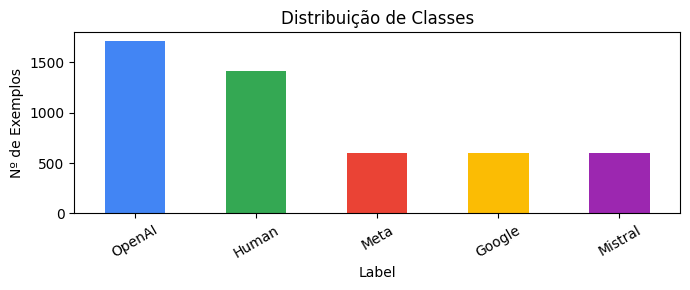

In [4]:
# Carregar dataset
df = pd.read_csv('../data/dataset_limpo.csv', sep=';').dropna(subset=['Text', 'Label'])

label2idx = {c: i for i, c in enumerate(CLASSES)}
idx2label = {i: c for c, i in label2idx.items()}

texts  = df['Text'].tolist()
labels = [label2idx[l] for l in df['Label']]

print(f"Total de exemplos: {len(texts)}")
print("\nDistribuição por classe:")
df['Label'].value_counts().plot(kind='bar', color=['#4285F4','#34A853','#EA4335','#FBBC04','#9C27B0'],
                                 figsize=(7, 3), title='Distribuição de Classes')
plt.ylabel('Nº de Exemplos')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [5]:
# Split treino / validação / teste
X_tr, X_te, y_tr, y_te = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tr, y_tr, test_size=VAL_SIZE/(1-TEST_SIZE), random_state=RANDOM_STATE, stratify=y_tr)

print(f"Treino:    {len(X_tr)} exemplos")
print(f"Validação: {len(X_val)} exemplos")
print(f"Teste:     {len(X_te)} exemplos")

Treino:    3451 exemplos
Validação: 493 exemplos
Teste:     987 exemplos


In [6]:
# Datasets TF-IDF (para Baseline e DNN) 
train_ds_tfidf = TfidfDataset(X_tr,  y_tr,  max_words=TFIDF_WORDS, train=True)
val_ds_tfidf   = TfidfDataset(X_val, y_val, vectorizer=train_ds_tfidf.vectorizer, train=False)
test_ds_tfidf  = TfidfDataset(X_te,  y_te,  vectorizer=train_ds_tfidf.vectorizer, train=False)

train_loader_tfidf = DataLoader(train_ds_tfidf, batch_size=BATCH_SIZE, shuffle=True)
val_loader_tfidf   = DataLoader(val_ds_tfidf,   batch_size=BATCH_SIZE)
test_loader_tfidf  = DataLoader(test_ds_tfidf,  batch_size=BATCH_SIZE)

# Datasets de Sequências (para LSTM / GRU) 
clean_tr  = [clean_text(t) for t in X_tr]
word_index = build_vocab(clean_tr, max_words=MAX_VOCAB)
vocab_size = len(word_index) + 2

train_ds_seq = SequenceDataset(X_tr,  y_tr,  word_index, max_len=MAX_LEN)
val_ds_seq   = SequenceDataset(X_val, y_val, word_index, max_len=MAX_LEN)
test_ds_seq  = SequenceDataset(X_te,  y_te,  word_index, max_len=MAX_LEN)

train_loader_seq = DataLoader(train_ds_seq, batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq   = DataLoader(val_ds_seq,   batch_size=BATCH_SIZE)
test_loader_seq  = DataLoader(test_ds_seq,  batch_size=BATCH_SIZE)

print(f"Vocabulário (Embeddings): {vocab_size} palavras")

Vocabulário (Embeddings): 10002 palavras


## Funções de Visualização

In [7]:
def plot_history(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], label='Treino',    color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Validação', color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].set_ylabel('Cross-Entropy Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], label='Treino',    color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Validação', color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Época')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_confusion(model, loader, title='Matriz de Confusão'):
    preds = predict(model, loader).numpy()
    true  = [int(y) for _, y in loader.dataset]
    cm = confusion_matrix(true, preds)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES)
    plt.title(title, fontweight='bold')
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')
    plt.tight_layout()
    plt.show()

    print(classification_report(true, preds, target_names=CLASSES))


---
## 2. Baseline — Regressão Logística (TF-IDF)

In [8]:
baseline = BaselineClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES)
criterion = nn.CrossEntropyLoss()

print("A treinar a Baseline (Regressão Logística + TF-IDF)...")
history_base = train(baseline, train_loader_tfidf, val_loader_tfidf, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar a Baseline (Regressão Logística + TF-IDF)...
Epoch 1/100 | train_loss: 1.5198 | train_acc: 0.5393 | val_loss: 1.5274 | val_acc: 0.4970
Epoch 2/100 | train_loss: 1.4451 | train_acc: 0.5790 | val_loss: 1.4602 | val_acc: 0.5497
Epoch 3/100 | train_loss: 1.3826 | train_acc: 0.5911 | val_loss: 1.4050 | val_acc: 0.5639
Epoch 4/100 | train_loss: 1.3275 | train_acc: 0.6036 | val_loss: 1.3569 | val_acc: 0.5680
Epoch 5/100 | train_loss: 1.2787 | train_acc: 0.6082 | val_loss: 1.3148 | val_acc: 0.5720
Epoch 6/100 | train_loss: 1.2346 | train_acc: 0.6134 | val_loss: 1.2771 | val_acc: 0.5761
Epoch 7/100 | train_loss: 1.1933 | train_acc: 0.6216 | val_loss: 1.2417 | val_acc: 0.6024
Epoch 8/100 | train_loss: 1.1546 | train_acc: 0.6303 | val_loss: 1.2089 | val_acc: 0.6045
Epoch 9/100 | train_loss: 1.1181 | train_acc: 0.6482 | val_loss: 1.1779 | val_acc: 0.6126
Epoch 10/100 | train_loss: 1.0839 | train_acc: 0.6642 | val_loss: 1.1491 | val_acc: 0.6187
Epoch 11/100 | train_loss: 1.0515 | train_ac

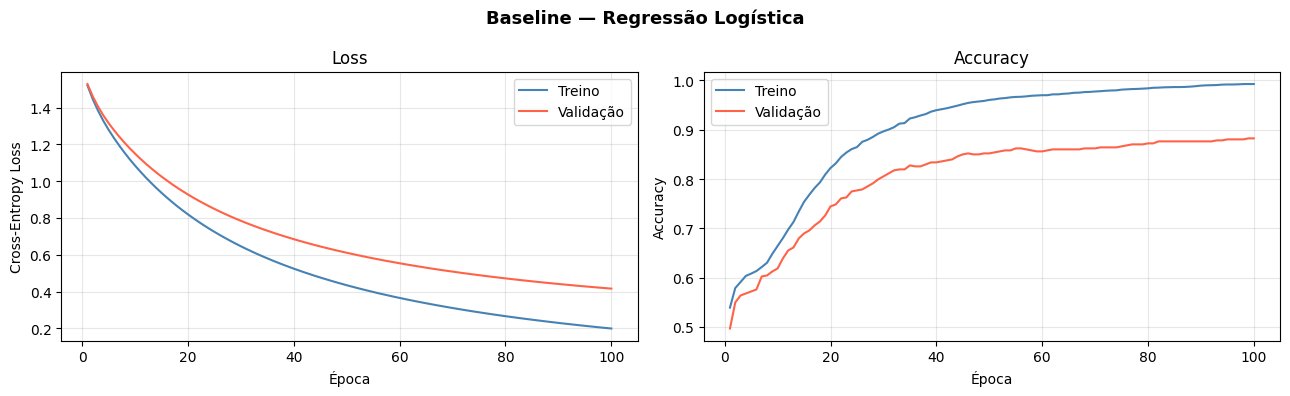


Accuracy no Teste (Baseline): 86.32%


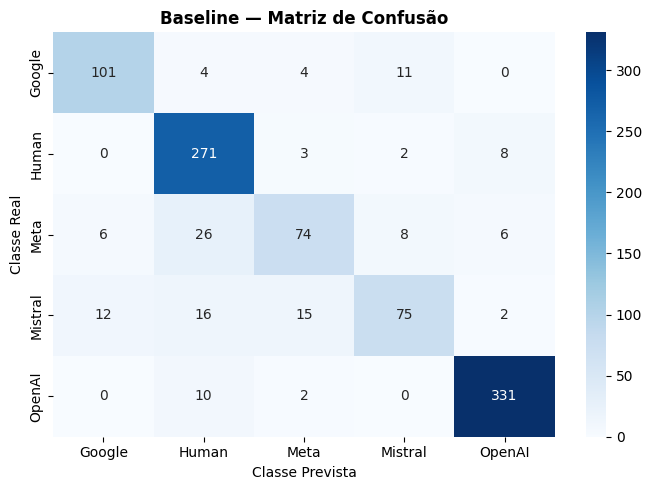

              precision    recall  f1-score   support

      Google       0.85      0.84      0.85       120
       Human       0.83      0.95      0.89       284
        Meta       0.76      0.62      0.68       120
     Mistral       0.78      0.62      0.69       120
      OpenAI       0.95      0.97      0.96       343

    accuracy                           0.86       987
   macro avg       0.83      0.80      0.81       987
weighted avg       0.86      0.86      0.86       987



In [9]:
plot_history(history_base, 'Baseline — Regressão Logística')
_, acc_base = evaluate(baseline, test_loader_tfidf)
print(f"\nAccuracy no Teste (Baseline): {acc_base*100:.2f}%")
plot_confusion(baseline, test_loader_tfidf, 'Baseline — Matriz de Confusão')

---
## 3. DNN — Deep Feedforward Network (TF-IDF)

In [10]:
dnn = DNNClassifier(
    input_dim=TFIDF_WORDS,
    n_classes=N_CLASSES,
    topology=[256, 128, 64],   # camadas ocultas
    dropout=0.3
)

print("A treinar DNN (TF-IDF)...")
history_dnn = train(dnn, train_loader_tfidf, val_loader_tfidf, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar DNN (TF-IDF)...
Epoch 1/100 | train_loss: 1.1318 | train_acc: 0.3527 | val_loss: 1.1502 | val_acc: 0.3509
Epoch 2/100 | train_loss: 0.4998 | train_acc: 0.7714 | val_loss: 0.5823 | val_acc: 0.7566
Epoch 3/100 | train_loss: 0.3629 | train_acc: 0.8392 | val_loss: 0.4845 | val_acc: 0.8012
Epoch 4/100 | train_loss: 0.2707 | train_acc: 0.8945 | val_loss: 0.4191 | val_acc: 0.8337
Epoch 5/100 | train_loss: 0.1753 | train_acc: 0.9533 | val_loss: 0.3892 | val_acc: 0.8540
Epoch 6/100 | train_loss: 0.1015 | train_acc: 0.9780 | val_loss: 0.4150 | val_acc: 0.8621
Epoch 7/100 | train_loss: 0.0674 | train_acc: 0.9875 | val_loss: 0.3848 | val_acc: 0.8560
Epoch 8/100 | train_loss: 0.0312 | train_acc: 0.9962 | val_loss: 0.4332 | val_acc: 0.8763
Epoch 9/100 | train_loss: 0.0218 | train_acc: 0.9959 | val_loss: 0.4815 | val_acc: 0.8722
Epoch 10/100 | train_loss: 0.0169 | train_acc: 0.9957 | val_loss: 0.4917 | val_acc: 0.8742
Epoch 11/100 | train_loss: 0.0110 | train_acc: 0.9977 | val_loss: 0.4895 

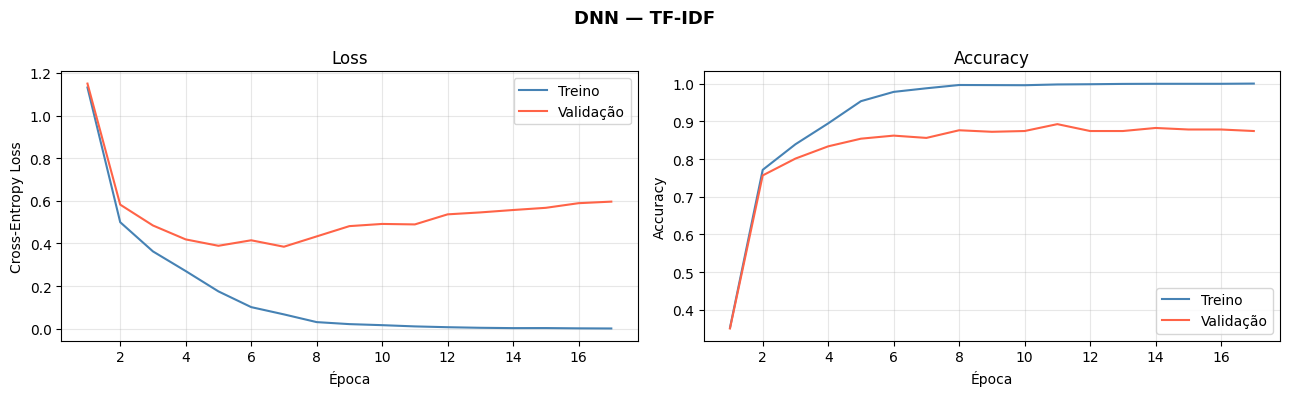


Accuracy no Teste (DNN): 86.22%


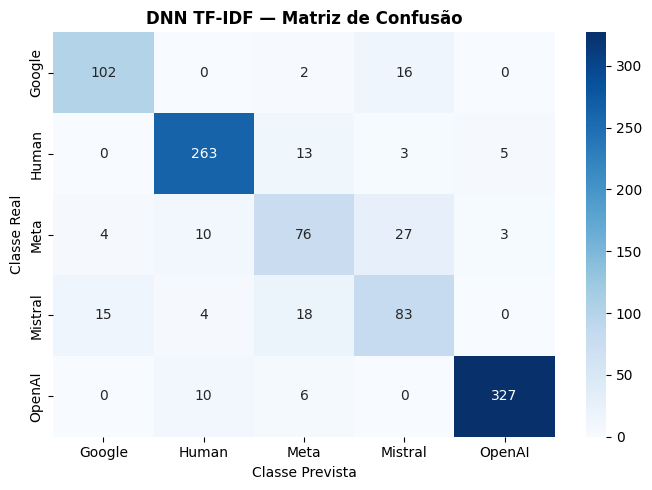

              precision    recall  f1-score   support

      Google       0.84      0.85      0.85       120
       Human       0.92      0.93      0.92       284
        Meta       0.66      0.63      0.65       120
     Mistral       0.64      0.69      0.67       120
      OpenAI       0.98      0.95      0.96       343

    accuracy                           0.86       987
   macro avg       0.81      0.81      0.81       987
weighted avg       0.86      0.86      0.86       987



In [11]:
plot_history(history_dnn, 'DNN — TF-IDF')
_, acc_dnn = evaluate(dnn, test_loader_tfidf)
print(f"\nAccuracy no Teste (DNN): {acc_dnn*100:.2f}%")
plot_confusion(dnn, test_loader_tfidf, 'DNN TF-IDF — Matriz de Confusão')

---
## 4. BiLSTM — Embeddings

In [12]:
lstm = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiLSTM (Embeddings)...")
history_lstm = train(lstm, train_loader_seq, val_loader_seq, criterion,
                     epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiLSTM (Embeddings)...
Epoch 1/100 | train_loss: 0.9210 | train_acc: 0.6424 | val_loss: 0.9837 | val_acc: 0.6105
Epoch 2/100 | train_loss: 0.8122 | train_acc: 0.7065 | val_loss: 0.8797 | val_acc: 0.6978
Epoch 3/100 | train_loss: 0.5015 | train_acc: 0.8090 | val_loss: 0.6838 | val_acc: 0.7383
Epoch 4/100 | train_loss: 0.3687 | train_acc: 0.8589 | val_loss: 0.5630 | val_acc: 0.7951
Epoch 5/100 | train_loss: 0.3111 | train_acc: 0.8864 | val_loss: 0.6670 | val_acc: 0.7708
Epoch 6/100 | train_loss: 0.2037 | train_acc: 0.9278 | val_loss: 0.5085 | val_acc: 0.8316
Epoch 7/100 | train_loss: 0.1982 | train_acc: 0.9331 | val_loss: 0.6116 | val_acc: 0.7586
Epoch 8/100 | train_loss: 0.0757 | train_acc: 0.9820 | val_loss: 0.5539 | val_acc: 0.8276
Epoch 9/100 | train_loss: 0.0540 | train_acc: 0.9861 | val_loss: 0.6029 | val_acc: 0.8195
Epoch 10/100 | train_loss: 0.0785 | train_acc: 0.9725 | val_loss: 0.6462 | val_acc: 0.8276
Epoch 11/100 | train_loss: 0.0236 | train_acc: 0.9951 | val_loss: 

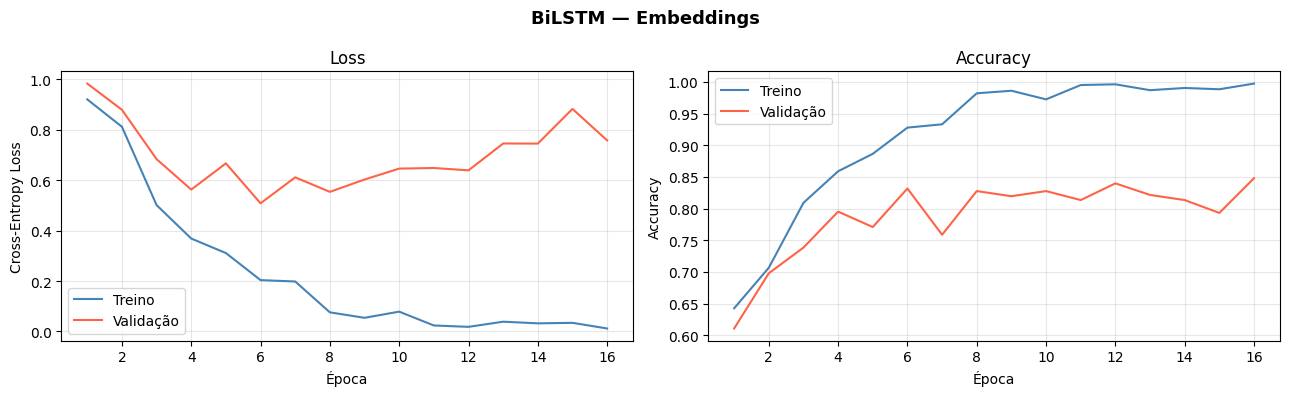


Accuracy no Teste (BiLSTM): 79.84%


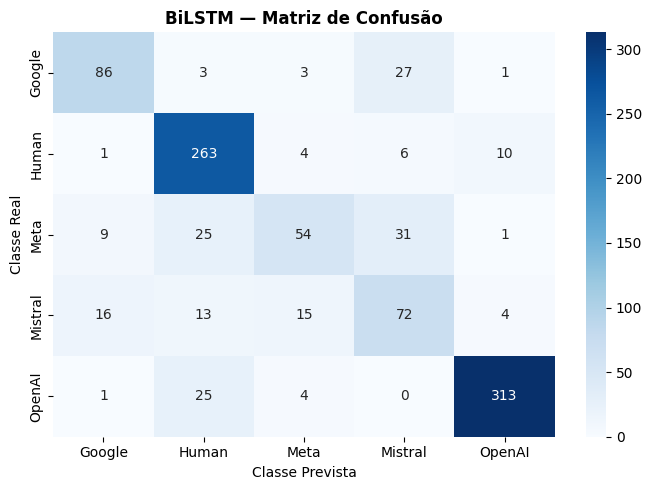

              precision    recall  f1-score   support

      Google       0.76      0.72      0.74       120
       Human       0.80      0.93      0.86       284
        Meta       0.68      0.45      0.54       120
     Mistral       0.53      0.60      0.56       120
      OpenAI       0.95      0.91      0.93       343

    accuracy                           0.80       987
   macro avg       0.74      0.72      0.73       987
weighted avg       0.80      0.80      0.79       987



In [13]:
plot_history(history_lstm, 'BiLSTM — Embeddings')
_, acc_lstm = evaluate(lstm, test_loader_seq)
print(f"\nAccuracy no Teste (BiLSTM): {acc_lstm*100:.2f}%")
plot_confusion(lstm, test_loader_seq, 'BiLSTM — Matriz de Confusão')

---
## 5. BiGRU — Embeddings

In [14]:
gru = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    n_classes=N_CLASSES,
    num_layers=2,
    dropout=0.3,
    bidirectional=True
)

print("A treinar BiGRU (Embeddings)...")
history_gru = train(gru, train_loader_seq, val_loader_seq, criterion,
                    epochs=EPOCHS, lr=LR, patience=PATIENCE, verbose=True)

A treinar BiGRU (Embeddings)...
Epoch 1/100 | train_loss: 0.8897 | train_acc: 0.6572 | val_loss: 1.0045 | val_acc: 0.6268
Epoch 2/100 | train_loss: 0.5885 | train_acc: 0.7772 | val_loss: 0.7572 | val_acc: 0.7262
Epoch 3/100 | train_loss: 0.3745 | train_acc: 0.8632 | val_loss: 0.5488 | val_acc: 0.7972
Epoch 4/100 | train_loss: 0.2696 | train_acc: 0.9122 | val_loss: 0.5496 | val_acc: 0.7931
Epoch 5/100 | train_loss: 0.1755 | train_acc: 0.9400 | val_loss: 0.5614 | val_acc: 0.7911
Epoch 6/100 | train_loss: 0.0804 | train_acc: 0.9783 | val_loss: 0.5099 | val_acc: 0.8316
Epoch 7/100 | train_loss: 0.1329 | train_acc: 0.9574 | val_loss: 0.7700 | val_acc: 0.8053
Epoch 8/100 | train_loss: 0.0283 | train_acc: 0.9930 | val_loss: 0.5831 | val_acc: 0.8195
Epoch 9/100 | train_loss: 0.0249 | train_acc: 0.9939 | val_loss: 0.6391 | val_acc: 0.8316
Epoch 10/100 | train_loss: 0.0071 | train_acc: 0.9997 | val_loss: 0.6319 | val_acc: 0.8479
Epoch 11/100 | train_loss: 0.0106 | train_acc: 0.9980 | val_loss: 0

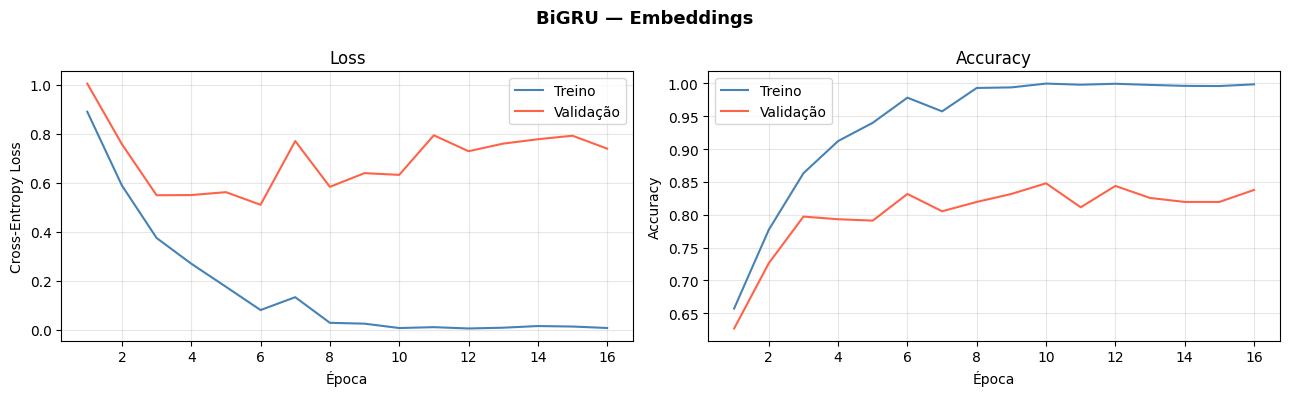


Accuracy no Teste (BiGRU): 80.65%


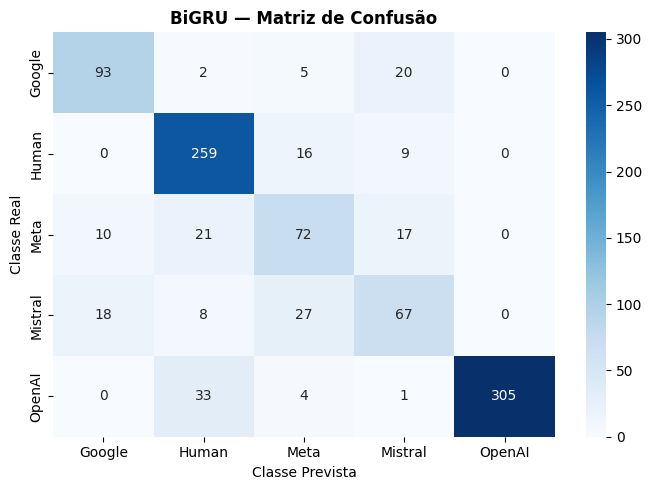

              precision    recall  f1-score   support

      Google       0.77      0.78      0.77       120
       Human       0.80      0.91      0.85       284
        Meta       0.58      0.60      0.59       120
     Mistral       0.59      0.56      0.57       120
      OpenAI       1.00      0.89      0.94       343

    accuracy                           0.81       987
   macro avg       0.75      0.75      0.75       987
weighted avg       0.81      0.81      0.81       987



In [15]:
plot_history(history_gru, 'BiGRU — Embeddings')
_, acc_gru = evaluate(gru, test_loader_seq)
print(f"\nAccuracy no Teste (BiGRU): {acc_gru*100:.2f}%")
plot_confusion(gru, test_loader_seq, 'BiGRU — Matriz de Confusão')

---
## 6. Comparação Final dos Modelos


 COMPARAÇÃO DE MODELOS — Accuracy no Teste
  Baseline (LogReg)      86.32%  ██████████████████████████████████
  DNN (TF-IDF)           86.22%  ██████████████████████████████████
  BiGRU                  80.65%  ████████████████████████████████
  BiLSTM                 79.84%  ███████████████████████████████


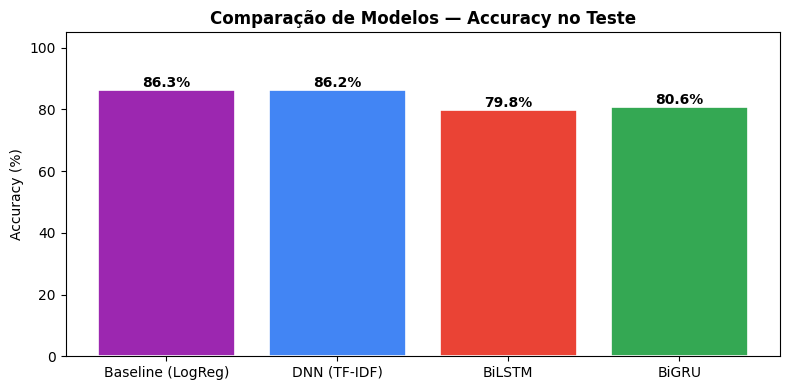

In [16]:
resultados = {
    'Baseline (LogReg)': acc_base,
    'DNN (TF-IDF)':      acc_dnn,
    'BiLSTM':            acc_lstm,
    'BiGRU':             acc_gru,
}

print("\n" + "="*45)
print(" COMPARAÇÃO DE MODELOS — Accuracy no Teste")
print("="*45)
for nome, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f"  {nome:<22} {acc*100:5.2f}%  {bar}")
print("="*45)

# Gráfico de barras
plt.figure(figsize=(8, 4))
nomes = list(resultados.keys())
accs  = [v * 100 for v in resultados.values()]
cores = ['#9C27B0', '#4285F4', '#EA4335', '#34A853']
bars  = plt.bar(nomes, accs, color=cores, edgecolor='white', linewidth=1.2)
plt.ylim(0, 105)
plt.ylabel('Accuracy (%)')
plt.title('Comparação de Modelos — Accuracy no Teste', fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             f'{acc:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Guardar os Modelos

In [17]:
import os
save_dir = '../models/pytorch_models/saved_models'
os.makedirs(save_dir, exist_ok=True)

torch.save(baseline.state_dict(), f'{save_dir}/baseline.pt')
torch.save(dnn.state_dict(),      f'{save_dir}/dnn_tfidf.pt')
torch.save(lstm.state_dict(),     f'{save_dir}/bilstm.pt')
torch.save(gru.state_dict(),      f'{save_dir}/bigru.pt')

print("Modelos guardados em:", save_dir)

Modelos guardados em: ../models/pytorch_models/saved_models


---
## 8. Carregar e Usar um Modelo Guardado

In [18]:
# Exemplo: carregar o DNN e classifcar um texto novo
model_loaded = DNNClassifier(input_dim=TFIDF_WORDS, n_classes=N_CLASSES, topology=[256, 128, 64], dropout=0.3)
model_loaded.load_state_dict(torch.load(f'{save_dir}/dnn_tfidf.pt', weights_only=True))
model_loaded.eval()

def classificar_texto(texto: str) -> str:
    x = train_ds_tfidf.vectorizer.transform([texto]).toarray()
    x_tensor = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = model_loaded(x_tensor)
        probs  = torch.softmax(logits, dim=1).squeeze()
    pred_idx = probs.argmax().item()
    print(f"Classe prevista: {CLASSES[pred_idx]}")
    print("Probabilidades:")
    for cls, p in zip(CLASSES, probs.tolist()):
        bar = '█' * int(p * 30)
        print(f"  {cls:<10} {p*100:5.1f}%  {bar}")
    return CLASSES[pred_idx]

# Testar com um texto
texto_teste = "The carbon cycle is a biogeochemical cycle where carbon is exchanged between the Earth's biosphere, atmosphere, and oceans."
classificar_texto(texto_teste)

Classe prevista: Human
Probabilidades:
  Google       0.0%  
  Human      100.0%  █████████████████████████████
  Meta         0.0%  
  Mistral      0.0%  
  OpenAI       0.0%  


'Human'